In [192]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

#TODO: At some point it would be nice to also visualize the centers for the flop.
#Doing this is a bit trickier, essentially would get implied "turn" EV in histogram space.

In [193]:
clust_path = Path.cwd().parent / 'clustering' / 'storage'  
print("The clustering path is: : ", str(clust_path))
rng_seed = 42

The clustering path is: :  /Users/franciscogomez-paz/code/pkrbots/clustering/storage


In [194]:
def load_matrix(path, col_names=None, dtype=np.float32):
    with open(path, 'rb') as f:
        rows, cols, bpe = np.fromfile(f, dtype=np.uint64, count=3)

        print("-------------------------------------------------------")
        print("Path: " + str(path))
        print(f"num_rows: {rows}, num_cols {cols}, bytes per elt: {bpe}")
        body = np.fromfile(f, dtype=dtype).reshape(rows, cols)
    return pd.DataFrame(body, columns=col_names)

In [195]:
def ev_std_dev(pdf_df):
    #assumes input is the unnormalizes pdf
    n_buckets = pdf_df.shape[1]
    step = 100/ n_buckets
    midpoints = np.arange(0, 100, step) + step / 2

    mass = pdf_df.values.astype(float)
    total = mass.sum(axis=1)
    ev = (mass * midpoints).sum(axis=1) / total
    var = (mass * (midpoints - ev[:, None])**2).sum(axis=1) / total
    std_dev = np.sqrt(var)
    return ev, std_dev

def plot_ev_std_dev(pdf_df, title):
    """Scatter each center in EV vs variance space."""
    ev, var = ev_std_dev(pdf_df)

    plt.figure(figsize=(6, 5))
    plt.scatter(ev, var, s=20)
    plt.xlabel('EV')
    plt.ylabel('Std Dev')

    if title == None:
        plt.title('EV vs Std Dev')
    else:
        plt.title(title)

    plt.show()

In [196]:
def plot_cluster_sizes(df, title):
    cluster_pct = df["assignment"].value_counts(normalize=True).mul(100).sort_index()
    cluster_pct.plot.bar(figsize=(8, 4), width=0.8)
    plt.xlabel("center")
    plt.ylabel("% of points")

    if title:
        plt.title(title)
    else:
        plt.title(" cluster sizes (% of total)")
    plt.show()

def plot_cluster_projections(df, title = None):
    ev, std_dev, labels = df["ev"], df["std_dev"], df["assignment"]

    centers = np.unique(labels)
    ncol = 8
    nrow = int(np.ceil(len(centers) / ncol))

    fig, axes = plt.subplots(nrow, ncol, figsize=(2 * ncol, 2 * nrow),
                             sharex=True, sharey=True)
    axes = axes.ravel()

    for ax, c in zip(axes, centers):
        m = (labels == c).values
        ax.scatter(ev[m], std_dev[m], s=3, alpha=0.4)
        ax.set_title(f"center {c}", fontsize=7)

    for ax in axes[len(centers):]:
        ax.axis("off")

    fig.supxlabel("EV"); fig.supylabel("Std Dev")
    fig.tight_layout()

    if title:
        plt.title(title)
    plt.show()

-------------------------------------------------------
Path: /Users/franciscogomez-paz/code/pkrbots/clustering/storage/river_strengths
num_rows: 123156254, num_cols 1, bytes per elt: 1


Text(0.5, 1.0, 'Number of Rivers per Strength')

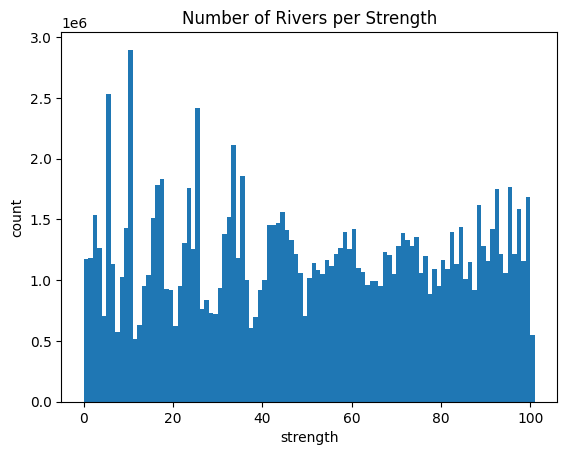

In [197]:
river_strength_path = str(clust_path) + "/river_strengths"
col_names = ["strength"]
river_df = load_matrix(path = river_strength_path, col_names =  col_names, dtype = np.int8)

plt.hist(river_df["strength"], bins=range(0, 102))
plt.xlabel('strength'); plt.ylabel('count')
plt.title("Number of Rivers per Strength")

In [198]:
turn_assignments_path = str(clust_path) + "/turn_assignments"
turn_assignments_df = load_matrix(path=turn_assignments_path, col_names=["assignment"], dtype=np.int16)

turn_cdfs_path = str(clust_path) + "/turn_cdfs"
turn_cdfs_df = load_matrix(path=turn_cdfs_path, dtype=np.int8)
turn_pdfs_df = turn_cdfs_df.diff(axis=1)
turn_pdfs_df.iloc[:, 0] = turn_cdfs_df.iloc[:, 0]

-------------------------------------------------------
Path: /Users/franciscogomez-paz/code/pkrbots/clustering/storage/turn_assignments
num_rows: 13960050, num_cols 1, bytes per elt: 2
-------------------------------------------------------
Path: /Users/franciscogomez-paz/code/pkrbots/clustering/storage/turn_cdfs
num_rows: 13960050, num_cols 20, bytes per elt: 1


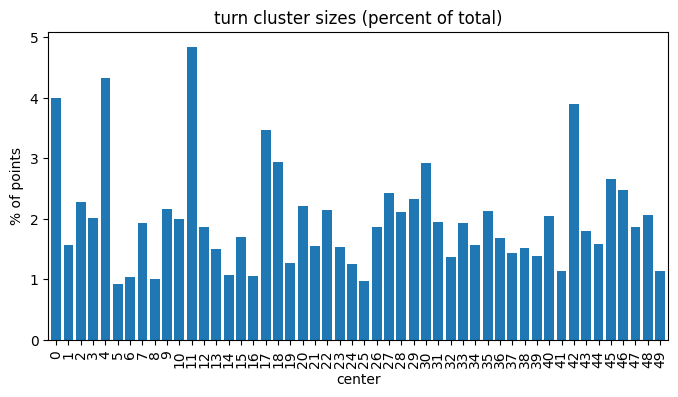

In [199]:
plot_cluster_sizes(turn_assignments_df, title = "turn cluster sizes (percent of total)")

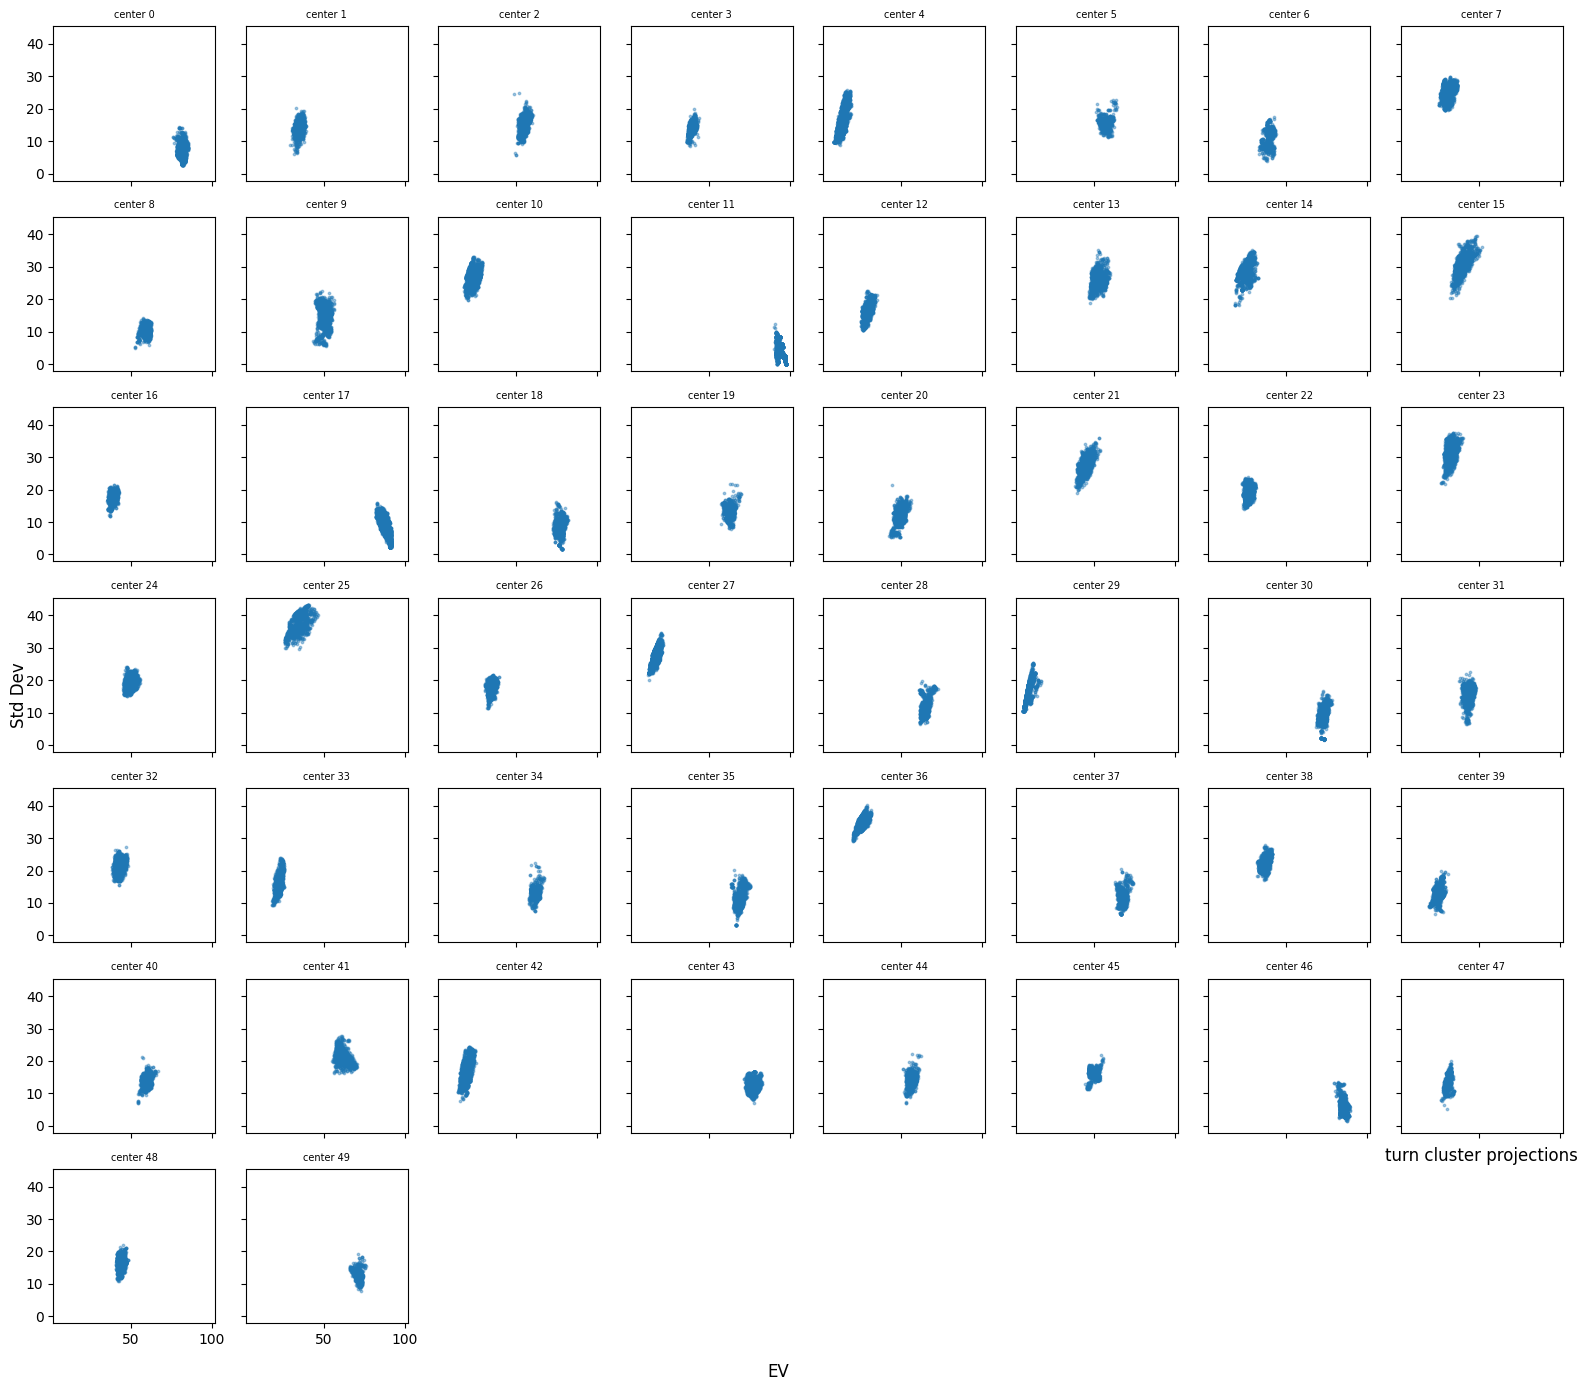

In [200]:
N = 100000
idxs = turn_pdfs_df.sample(n=min(N, len(turn_pdfs_df)), random_state=rng_seed).index
sub_pdfs = turn_pdfs_df.loc[idxs].reset_index(drop=True)
sub_assignments = turn_assignments_df.loc[idxs].reset_index(drop=True)

ev, std_dev = ev_std_dev(sub_pdfs)
sub_df = pd.DataFrame({"ev": ev, "std_dev": std_dev, "assignment": sub_assignments["assignment"]})

plot_cluster_projections(sub_df, "turn cluster projections")

In [201]:
turn_centers_path = str(clust_path) + "/turn_cdf_centers"
turn_centers_df = load_matrix(path=turn_centers_path, col_names=None, dtype=np.int8)

pdf_df = turn_centers_df.diff(axis=1)
pdf_df.iloc[:, 0] = turn_centers_df.iloc[:, 0]

-------------------------------------------------------
Path: /Users/franciscogomez-paz/code/pkrbots/clustering/storage/turn_cdf_centers
num_rows: 50, num_cols 20, bytes per elt: 1


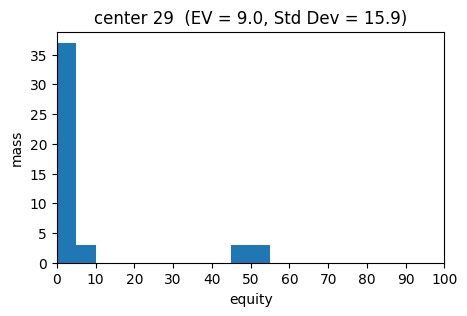

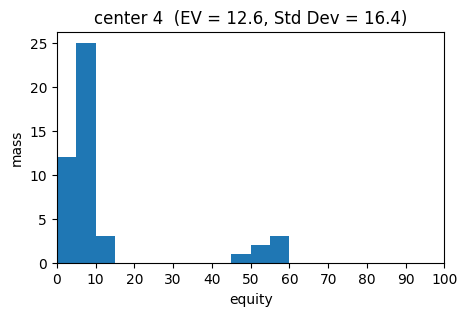

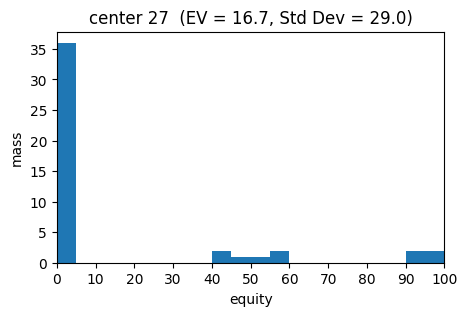

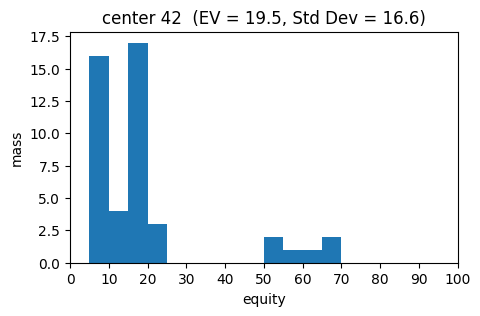

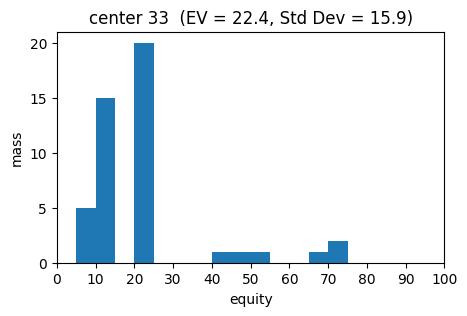

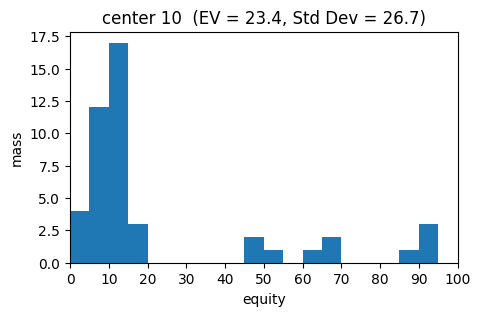

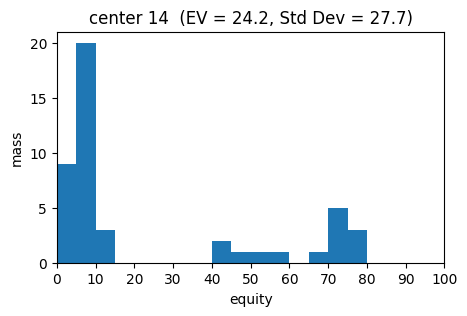

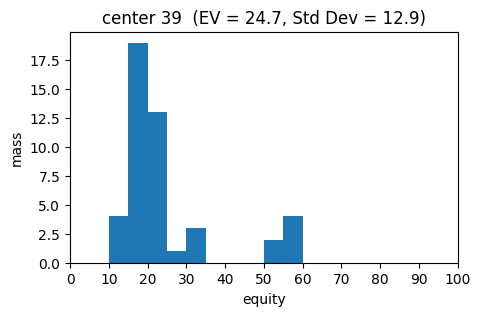

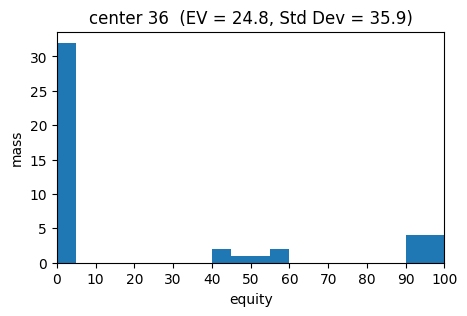

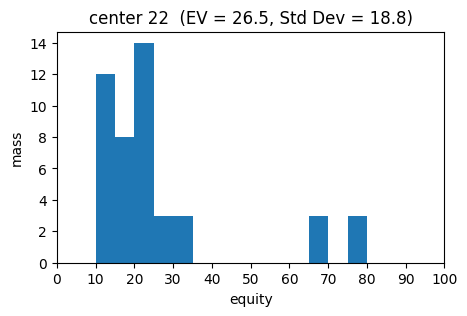

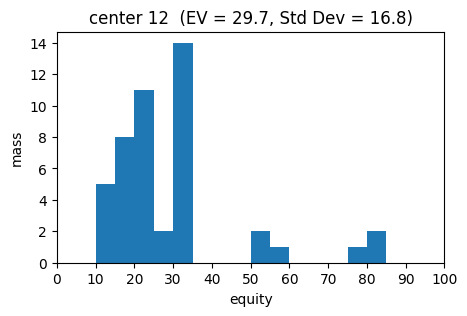

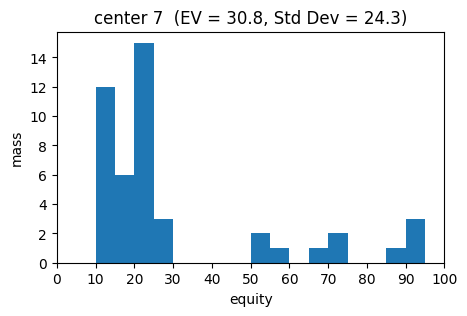

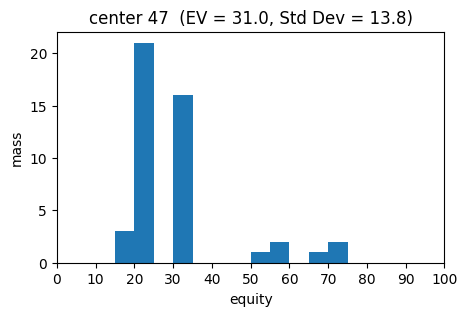

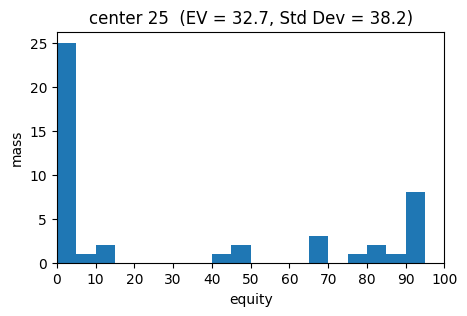

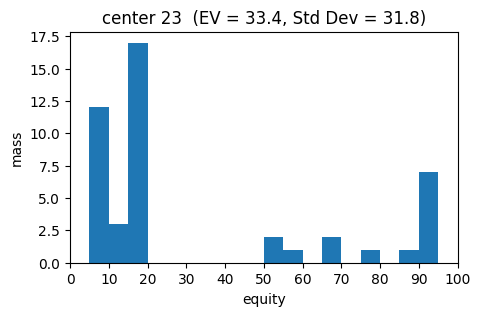

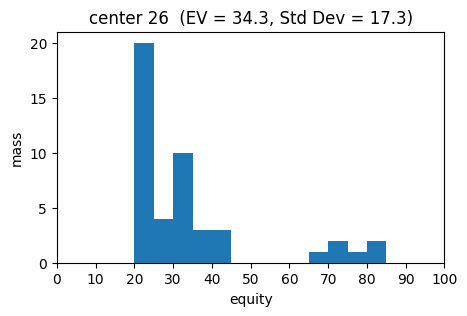

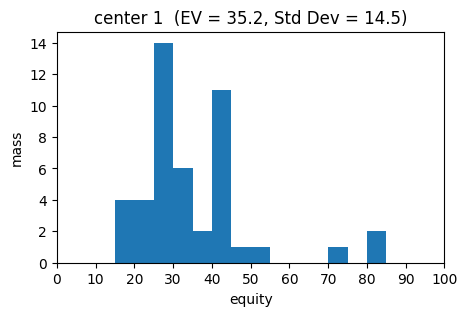

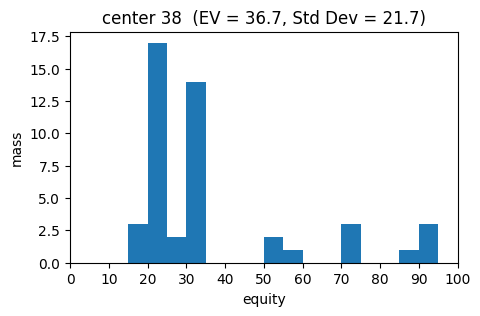

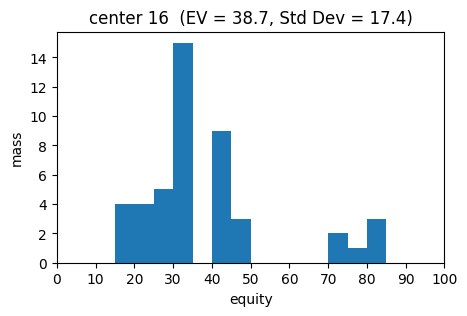

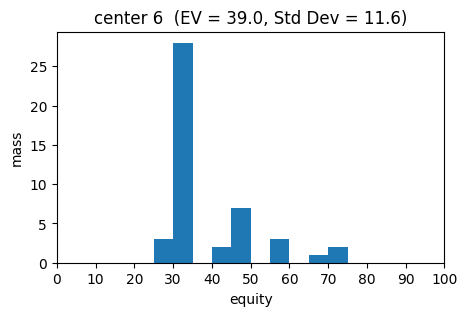

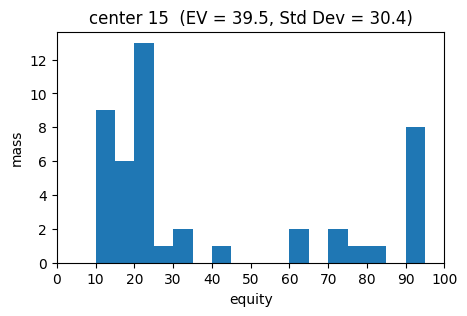

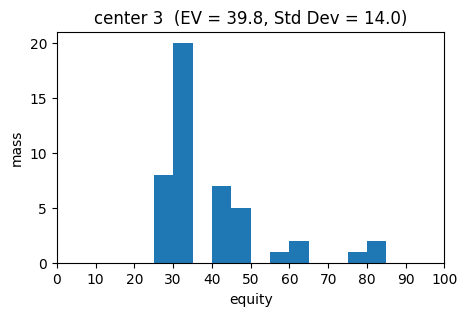

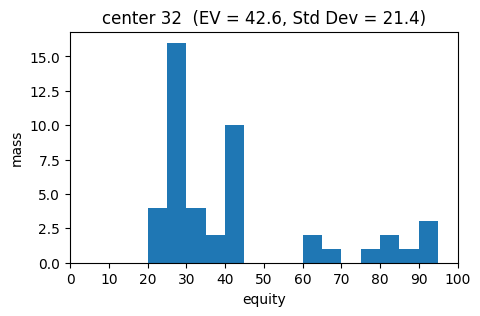

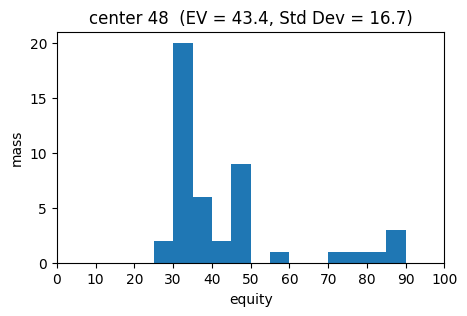

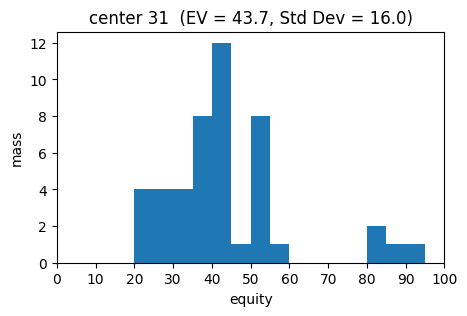

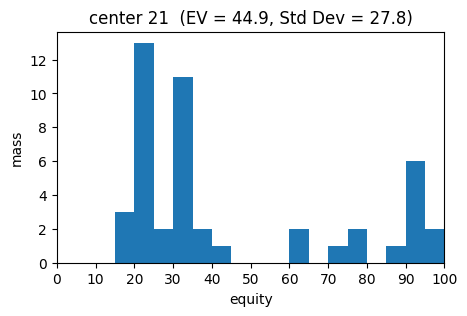

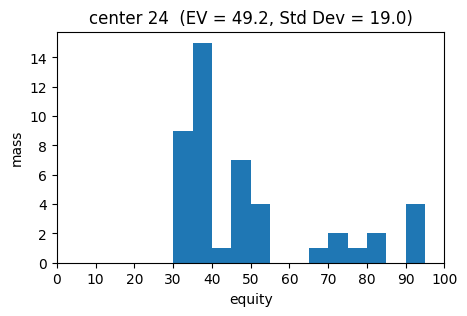

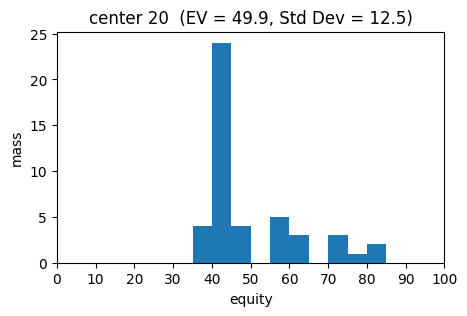

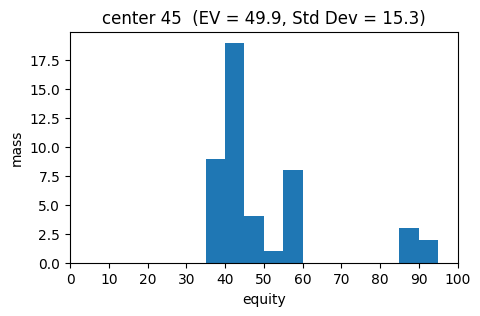

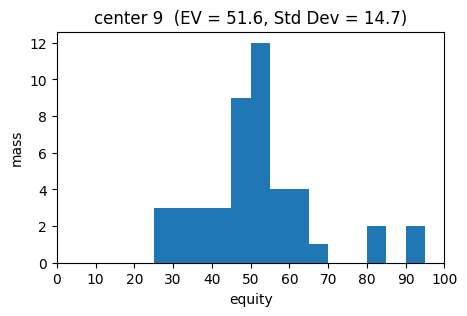

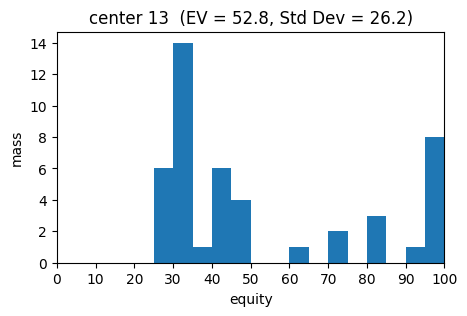

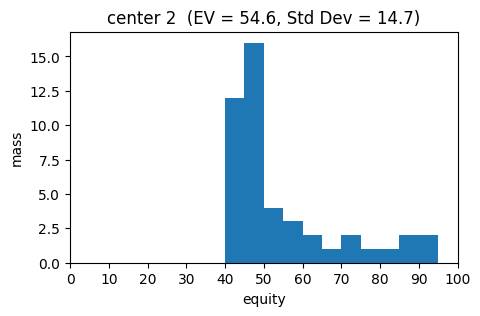

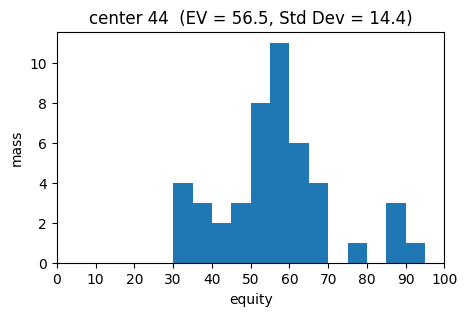

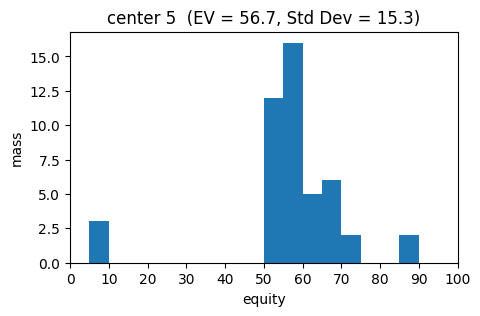

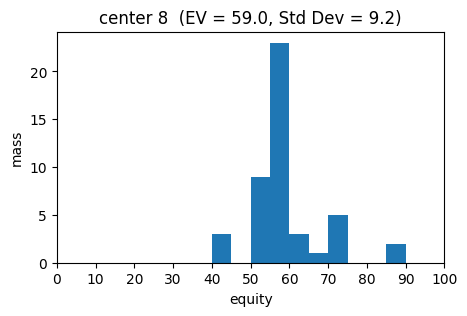

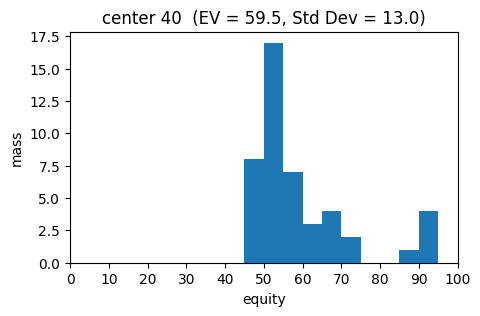

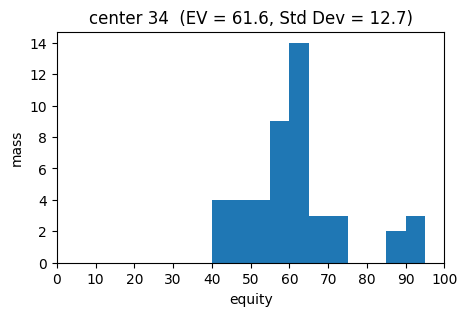

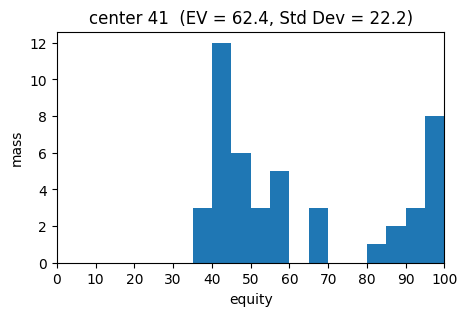

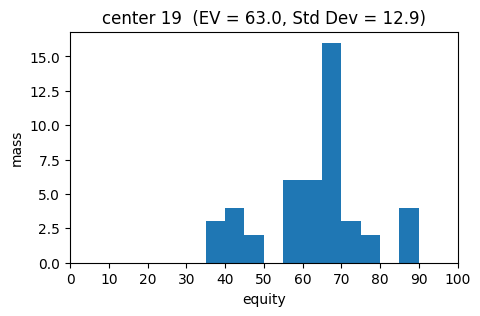

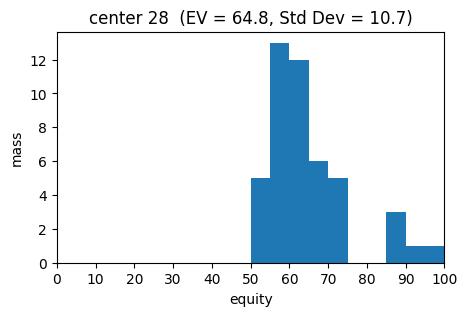

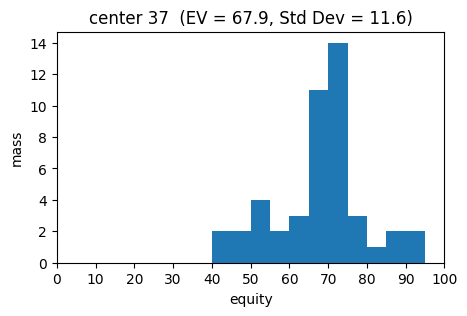

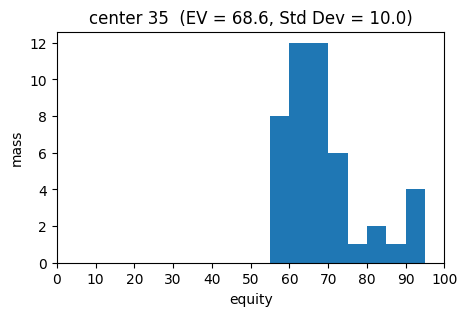

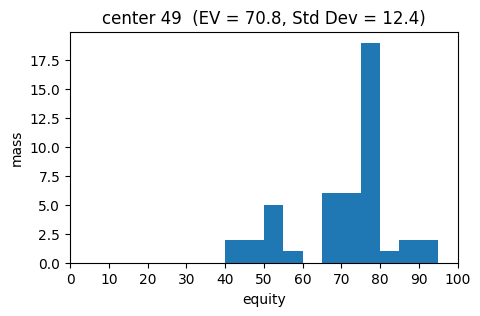

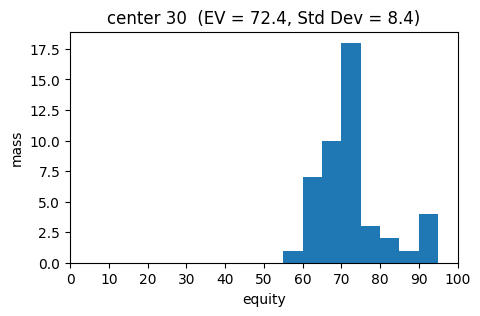

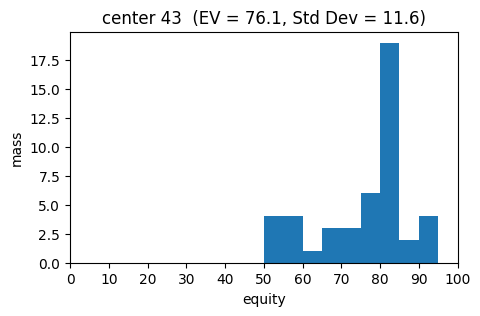

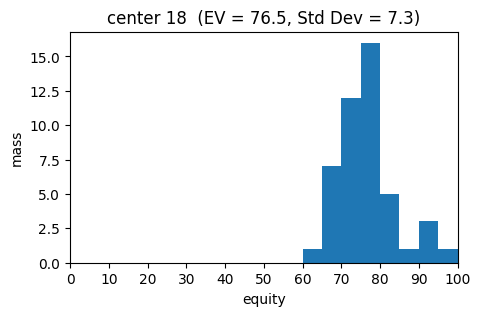

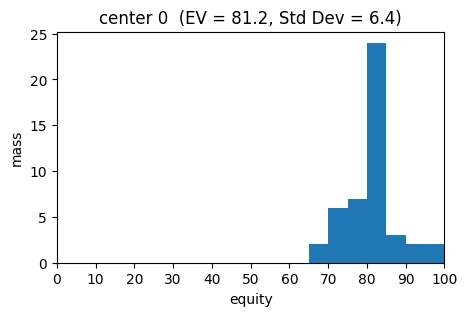

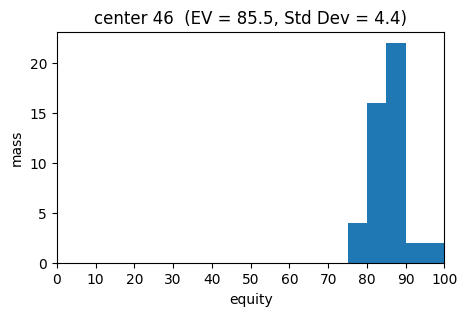

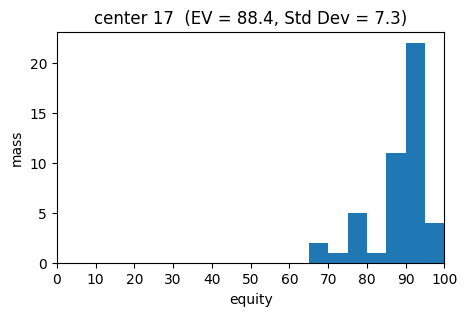

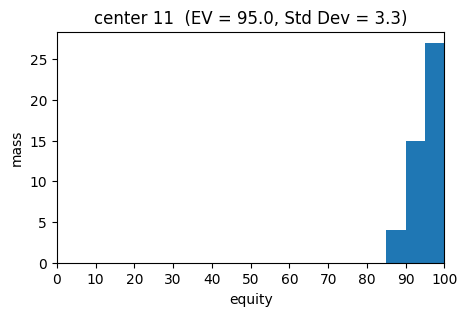

In [202]:
n_buckets = pdf_df.shape[1]
step = int(100 / n_buckets)
edges = np.arange(0, 100, step)

mass = pdf_df.values.astype(float)
ev, std_dev = ev_std_dev(pdf_df)
order = np.argsort(ev)            
                   
for pos in order:
    idx = pdf_df.index[pos]
    row = pdf_df.iloc[pos]
    plt.figure(figsize=(5, 3))
    plt.bar(edges, row.values, width=step, align='edge')
    plt.xlim(0, 100)
    plt.xticks(range(0, 101, 10))
    plt.title(f'center {idx}  (EV = {ev[pos]:.1f}, Std Dev = {std_dev[pos]:.1f})')
    plt.xlabel('equity'); plt.ylabel('mass')
    plt.show()

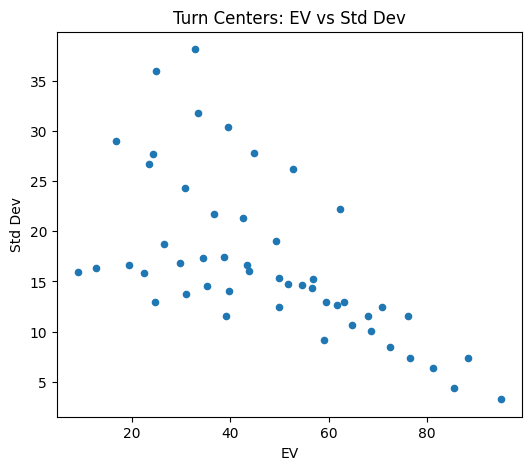

In [203]:
plot_ev_std_dev(pdf_df, title = "Turn Centers: EV vs Std Dev")

In [204]:
ev_sdev_path = str(clust_path) + "/flop_ev_sdev"
flop_ev_sdev = load_matrix(ev_sdev_path, col_names= ["ev", "std_dev"], dtype = np.int8)

flop_ass_path = str(clust_path) + "/flop_assignments"
flop_assignments = load_matrix(flop_ass_path, col_names = ["assignment"], dtype = np.int16)

-------------------------------------------------------
Path: /Users/franciscogomez-paz/code/pkrbots/clustering/storage/flop_ev_sdev
num_rows: 1286792, num_cols 2, bytes per elt: 1
-------------------------------------------------------
Path: /Users/franciscogomez-paz/code/pkrbots/clustering/storage/flop_assignments
num_rows: 1286792, num_cols 1, bytes per elt: 2


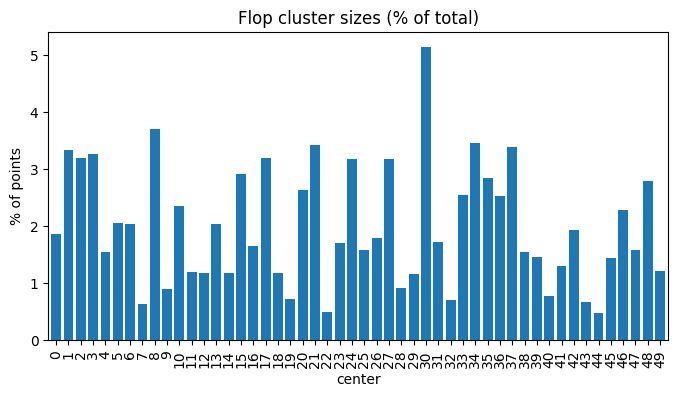

In [205]:
plot_cluster_sizes(flop_assignments, "Flop cluster sizes (% of total)")

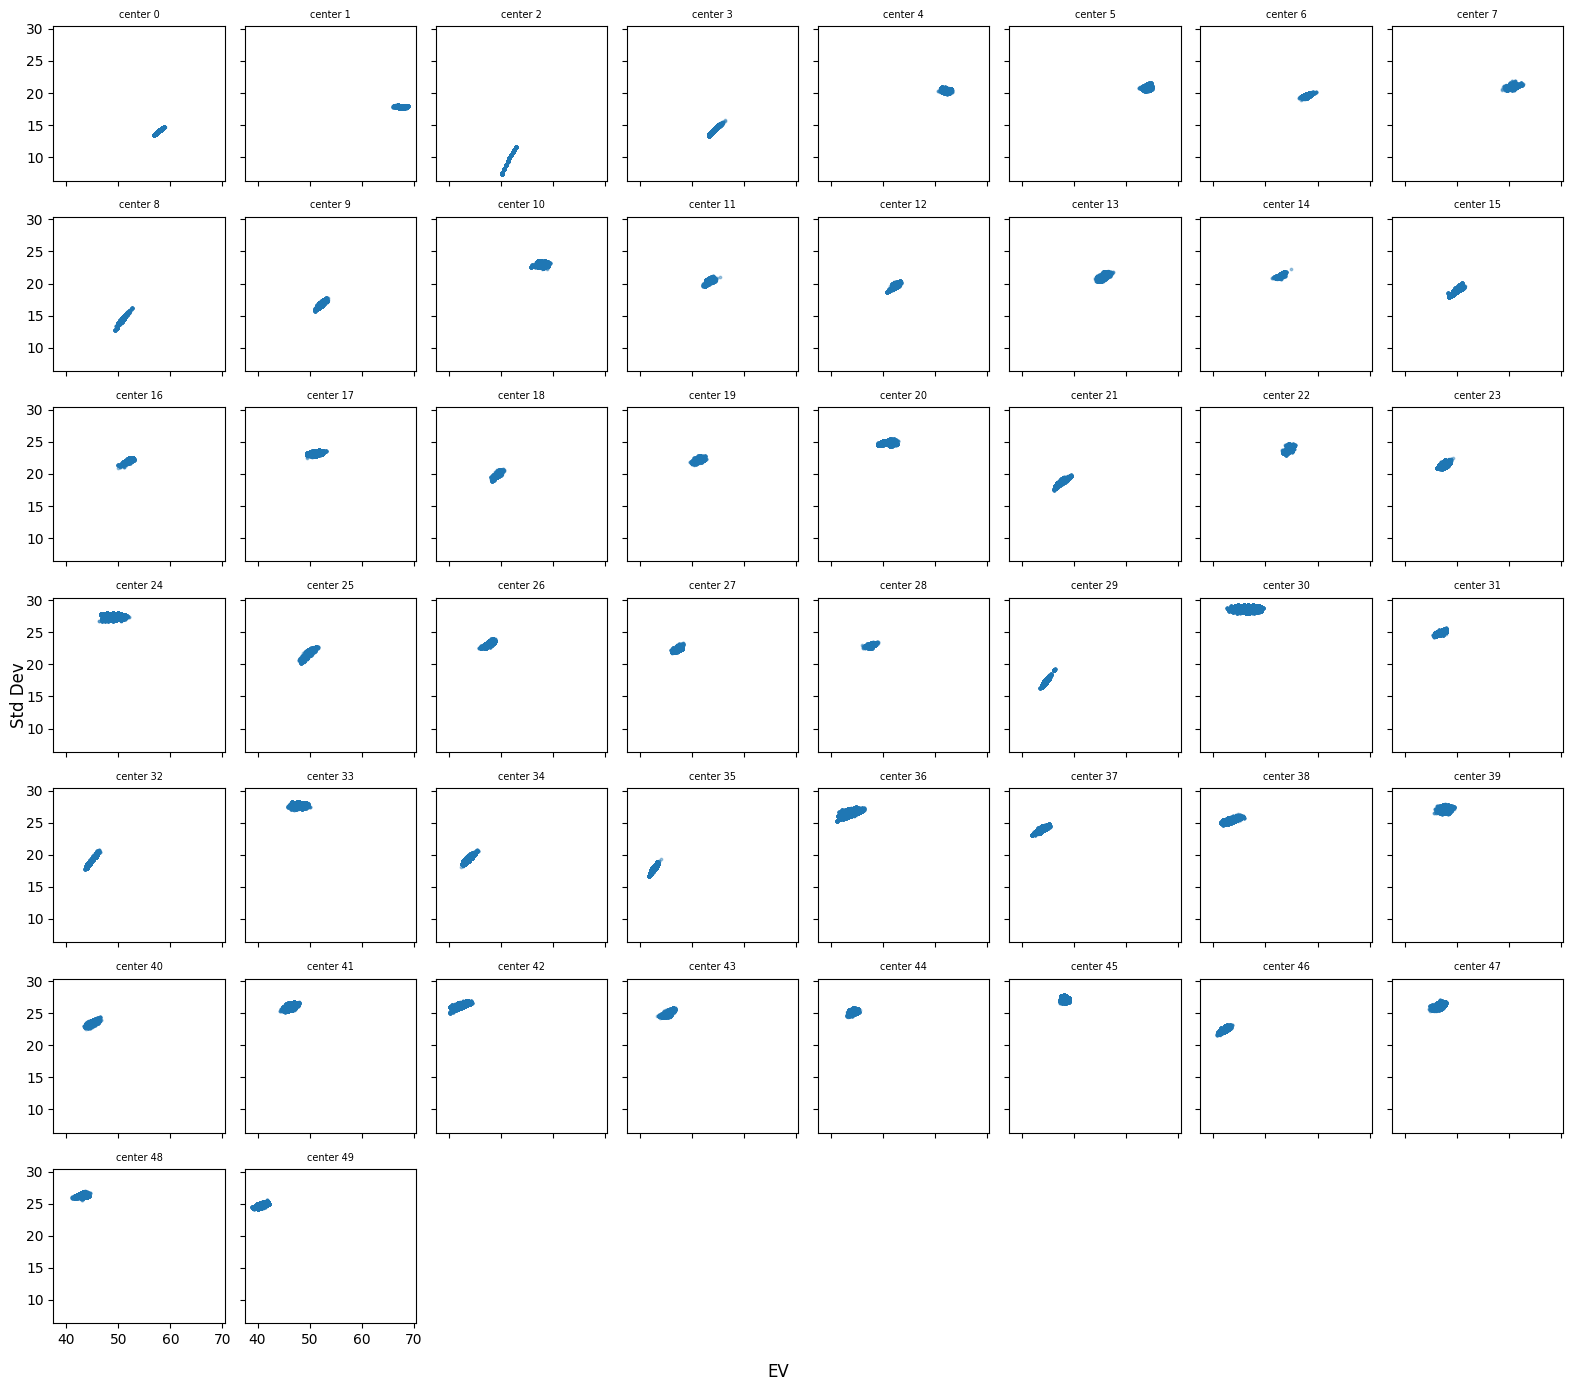

In [206]:
N = 1000000
merged_df = flop_assignments.merge(flop_ev_sdev, left_index = True, right_index = True)
idxs = merged_df.sample(n=min(N, len(merged_df)), random_state=rng_seed).index 
sub_df = merged_df.iloc[idxs]
ev, std_dev = ev_std_dev(sub_df)

df = pd.DataFrame({"ev": ev, "std_dev": std_dev, "assignment": sub_df["assignment"]})
plot_cluster_projections(df)